## Implement Logistic Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:

def single_proba(Xrow, W):
    assert len(W) > 1, "Unexpected W size. Function works with 2 or more features."
    assert len(Xrow) + 1 == len(W), "Invalid args. The sizes of X and W arrays are not consistent!"

    L = W[0]
    for i in range(1, len(W)):
        L += W[i] * Xrow[i-1]

    result = 1 / (1 + np.exp(-L))
    if np.isclose(result, 1):
        return 0.99999
    else:
        return result
    
def proba(X, W):
    result = []
    for Xrow in X:
        result.append(single_proba(Xrow, W))
    return result

def cost(preds, Ytrain):
    assert len(preds) == len(Ytrain), "Cost function invalid args!"
    sum = 0;
    for i in range(len(preds)):
        sum += Ytrain[i] * np.log(preds[i]) + (1-Ytrain[i]) * np.log(1-preds[i])
    return -1 * sum

    # Logloss derivative with respect to Wi
def logloss_der_wrt_w(w_index, Xtrain, Ytrain, probs):
    assert len(probs) == len(Ytrain), "Derivative function invalid args!"
    if w_index == 0:
        return (-1 / len(probs)) * np.sum(np.array(Ytrain) - np.array(probs))
    else:
        xi = Xtrain[:, w_index - 1 : w_index]
        return (-1 / len(probs)) * np.sum((np.array(Ytrain) - np.array(probs)) * np.array(xi))

def w_rmsprop(w_index, Xtrain, Ytrain, probs, sq_der_avg_list, rho):
    # https://habr.com/ru/articles/318970/
    # https://machinelearningmastery.com/gradient-descent-with-rmsprop-from-scratch/
    der = logloss_der_wrt_w(w_index, Xtrain, Ytrain, probs)
    sq_der = der**2.0
    
    # update the moving average of the squared gradient
    sq_der_avg_list[w_index] = (sq_der_avg_list[w_index] * rho) + (sq_der * (1.0-rho))
    alpha = 1 / (1e-8 + np.sqrt(sq_der_avg_list[w_index]))
    return alpha * der

def nesterov(W, last_W_increment, Xtrain, Ytrain, rho, learning_rate):
    # https://habr.com/ru/articles/318970/
    assert len(last_W_increment) == len(W), "Nesterov invalid args!"
    W_corrected = np.array(W) - rho * np.array(last_W_increment)
    probas_corrected = proba(Xtrain, W_corrected)
    
    for i in range(len(last_W_increment)):
        der_corrected = logloss_der_wrt_w(i, Xtrain, Ytrain, probas_corrected)
        last_W_increment[i] = rho * last_W_increment[i] + learning_rate * der_corrected
    return last_W_increment

def proba_to_pred(probs):
    return [1 if x > 0.5 else 0 for x in probs]

class LogReg:
    def __init__(self, lr = 0.1, epochs = 100, optimization = ''):
        self.__COSTS__ = []
        self.__PROBS__ = []
        self.__PREDS__ = []
        self.__PARAMS__ = []
        self.__LEARNING_RATE__ = lr
        self.__EPOCHS__ = epochs
        self.__OPT__ = optimization

    def fit(self, Xtrain, Ytrain):
        self.__COSTS__.clear()
        self.__PROBS__.clear()
        self.__PREDS__.clear()
        self.__PARAMS__.clear()
        
        assert len(Xtrain) > 1, "Fit invalid args!"
        assert len(Xtrain[0]) > 1, "Fit invalid args!"
        
        # Start values
        rng = np.random.default_rng(seed = 42)
        W = rng.normal(size = len(Xtrain[0]) + 1)
        self.__PARAMS__.append(W.copy())

        # RMSProp square deriviative average
        sq_der_avg = [0] * len(W)
        # Nesterov momentum last parameters increment
        last_W_increment = [0] * len(W)
        
        rho = 0.9
        
        for _ in range(self.__EPOCHS__):
            probs = proba(Xtrain, W)
            self.__PROBS__.append(probs)
            self.__PREDS__.append(proba_to_pred(probs))
            self.__COSTS__.append(cost(probs, Ytrain))
            
            if self.__OPT__ == '':
                for i in range(len(W)):
                    W[i] -= self.__LEARNING_RATE__ * logloss_der_wrt_w(i, Xtrain, Ytrain, probs)
            elif self.__OPT__ == 'RMSProp':
                for i in range(len(W)):
                    W[i] -= self.__LEARNING_RATE__ * w_rmsprop(i, Xtrain, Ytrain, probs, sq_der_avg, rho)
            elif self.__OPT__ == 'Nesterov':
                W -= nesterov(W, last_W_increment, Xtrain, Ytrain, rho, self.__LEARNING_RATE__)
            else:
                assert False, "Fit invalid args! Unknown optimization method."
                
            self.__PARAMS__.append(W.copy())

    def predict(self, Xtest):
        assert len(self.__PARAMS__) > 1, "Model not trained!"
        return proba_to_pred(proba(Xtest, self.__PARAMS__[-1]))
    
    def accuracy_score(self, preds, Ytest):
        assert len(preds) > 0, "Invalid accuracy_score args!"
        assert len(preds) == len(Ytest), "Invalid accuracy_score args!"
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for i in range(len(preds)):
            if Ytest[i] == 0 and preds[i] == 0:
                tn+=1
            elif Ytest[i] == 0 and preds[i] == 1:
                fp+=1
            elif Ytest[i] == 1 and preds[i] == 0:
                fn+=1
            elif Ytest[i] == 1 and preds[i] == 1:
                tp+=1
            else:
                assert False, "Should not be here!"
        return (tp + tn) / (tp + tn + fp + fn)

## Import only utilities from sklearn

In [3]:
from sklearn import datasets, model_selection, preprocessing

## Load dataset and prepare train and test data

In [4]:
iris = datasets.load_iris()
X = iris.data[:, :2]

In [5]:
Y = iris.target

In [6]:
#normalizer = preprocessing.Normalizer().fit(X)
#X_train, X_test, Y_train, Y_test = model_selection.train_test_split(normalizer.transform(X), Y, test_size=0.2, random_state=42)
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=42)

Y_train_1 = [1 if x == 0 else 0 for x in Y_train]
Y_test_1 = [1 if x == 0 else 0 for x in Y_test]

Y_train_2 = [1 if x == 1 else 0 for x in Y_train]
Y_test_2 = [1 if x == 1 else 0 for x in Y_test]

Y_train_3 = [1 if x == 2 else 0 for x in Y_train]
Y_test_3 = [1 if x == 2 else 0 for x in Y_test]

print(Y_train[:20])
print(Y_train_1[:20])
print(Y_train_2[:20])
print(Y_train_3[:20])

# print(Y_test_1[:20])
# print(Y_test_2[:20])
# print(Y_test_3[:20])

[0 0 1 0 0 2 1 0 0 0 2 1 1 0 0 1 2 2 1 2]
[1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0]
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1]


## Predict. Common case.

0.7666666666666667
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
0.5666666666666667
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
0.5333333333333333
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]


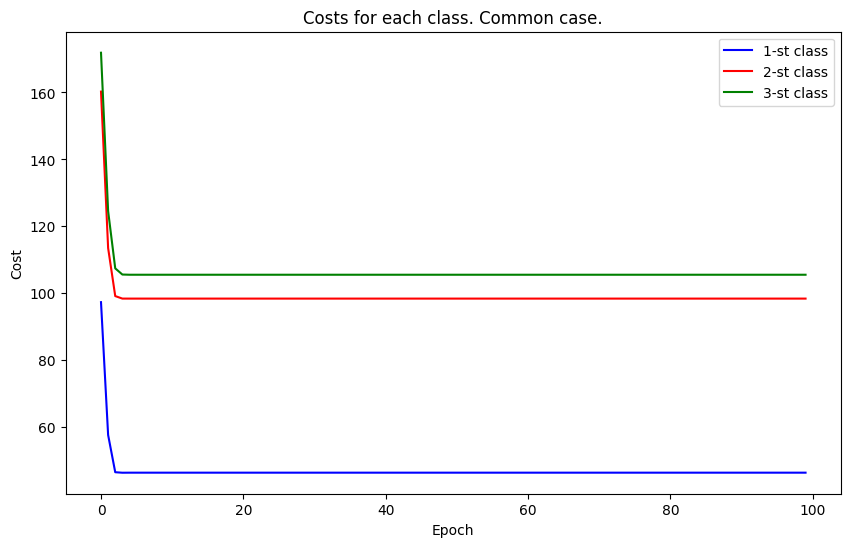

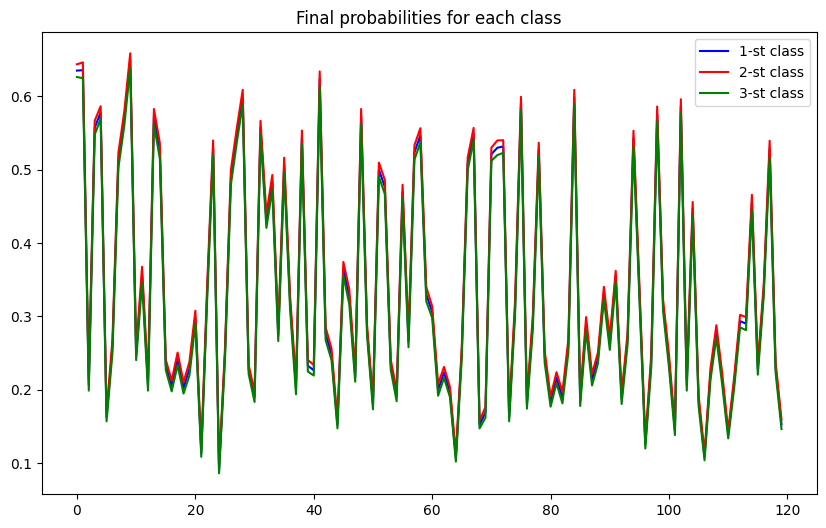

In [7]:
log_reg_cc_1 = LogReg(epochs = 100, lr = 0.001)
log_reg_cc_1.fit(X_train, Y_train_1)
preds_cc_1 = log_reg_cc_1.predict(X_test)
score_cc_1 = log_reg_cc_1.accuracy_score(preds_cc_1, Y_test_1)

print(score_cc_1)
print(preds_cc_1[:20])

log_reg_cc_2 = LogReg(epochs = 100, lr = 0.001)
log_reg_cc_2.fit(X_train, Y_train_2)
preds_cc_2 = log_reg_cc_2.predict(X_test)
score_cc_2 = log_reg_cc_2.accuracy_score(preds_cc_2, Y_test_2)

print(score_cc_2)
print(preds_cc_2[:20])

log_reg_cc_3 = LogReg(epochs = 100, lr = 0.001)
log_reg_cc_3.fit(X_train, Y_train_3)
preds_cc_3 = log_reg_cc_3.predict(X_test)
score_cc_3 = log_reg_cc_3.accuracy_score(preds_cc_3, Y_test_3)

print(score_cc_3)
print(preds_cc_3[:20])

plt.figure(figsize=(10, 6))
plt.title('Costs for each class. Common case.')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.plot(log_reg_cc_1.__COSTS__, color = 'blue', label = '1-st class')
plt.plot(log_reg_cc_2.__COSTS__, color = 'red', label = '2-st class')
plt.plot(log_reg_cc_3.__COSTS__, color = 'green', label = '3-st class')
plt.legend(loc = 1)
plt.show()

# Почти одинаковые вероятности почему-то...
plt.figure(figsize=(10, 6))
plt.title('Final probabilities for each class')
plt.plot(log_reg_cc_1.__PROBS__[-1], color = 'blue', label = '1-st class')
plt.plot(log_reg_cc_2.__PROBS__[-1], color = 'red', label = '2-st class')
plt.plot(log_reg_cc_3.__PROBS__[-1], color = 'green', label = '3-st class')
plt.legend(loc = 1)
plt.show()

## Predict. RMSProp.

0.8333333333333334
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
0.5333333333333333
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
0.5333333333333333
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]


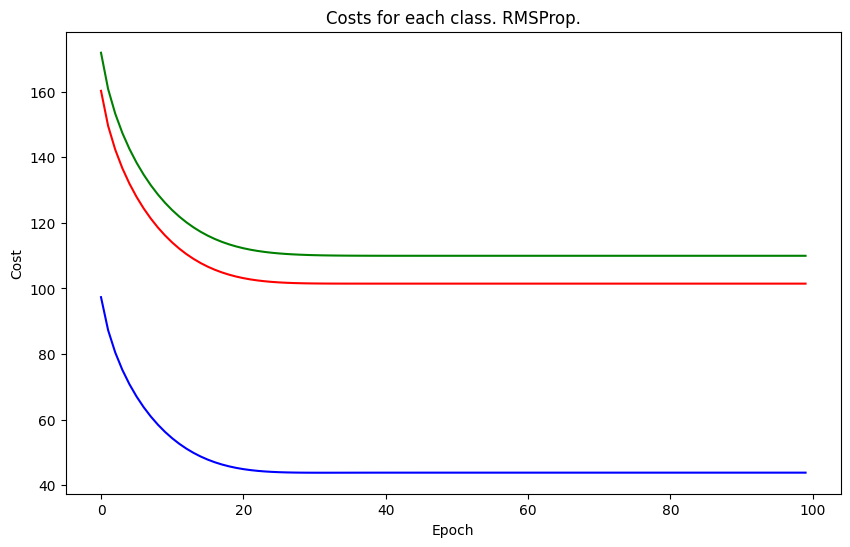

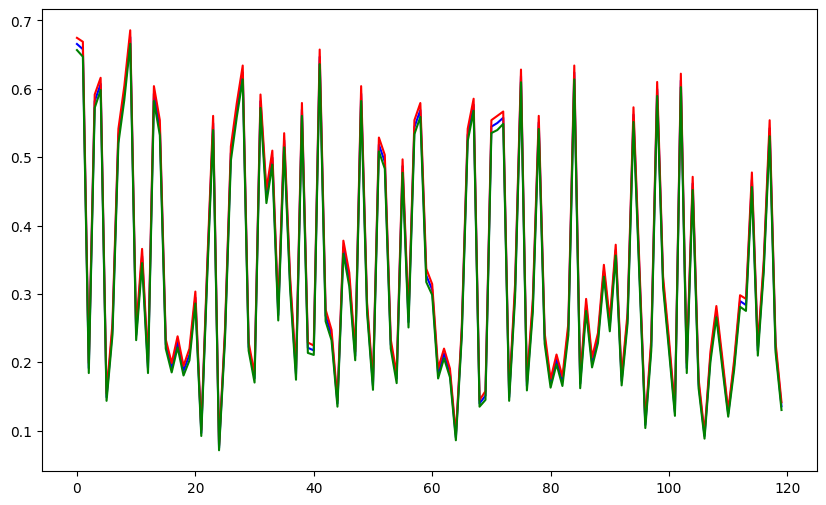

In [8]:
log_reg_rmsprop_1 = LogReg(epochs = 100, lr = 0.01, optimization = 'RMSProp')
log_reg_rmsprop_1.fit(X_train, Y_train_1)
preds_rmsprop_1 = log_reg_rmsprop_1.predict(X_test)
score_rmsprop_1 = log_reg_rmsprop_1.accuracy_score(preds_rmsprop_1, Y_test_1)

print(score_rmsprop_1)
print(preds_rmsprop_1[:20])

log_reg_rmsprop_2 = LogReg(epochs = 100, lr = 0.01, optimization = 'RMSProp')
log_reg_rmsprop_2.fit(X_train, Y_train_2)
preds_rmsprop_2 = log_reg_rmsprop_2.predict(X_test)
score_rmsprop_2 = log_reg_rmsprop_2.accuracy_score(preds_rmsprop_2, Y_test_2)

print(score_rmsprop_2)
print(preds_rmsprop_2[:20])

log_reg_rmsprop_3 = LogReg(epochs = 100, lr = 0.01, optimization = 'RMSProp')
log_reg_rmsprop_3.fit(X_train, Y_train_3)
preds_rmsprop_3 = log_reg_rmsprop_3.predict(X_test)
score_rmsprop_3 = log_reg_rmsprop_3.accuracy_score(preds_rmsprop_3, Y_test_3)

print(score_rmsprop_3)
print(preds_rmsprop_3[:20])

plt.figure(figsize=(10, 6))
plt.title('Costs for each class. RMSProp.')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.plot(log_reg_rmsprop_1.__COSTS__, color = 'blue', label = '1-st class')
plt.plot(log_reg_rmsprop_2.__COSTS__, color = 'red', label = '2-st class')
plt.plot(log_reg_rmsprop_3.__COSTS__, color = 'green', label = '3-st class')
plt.show()

# Одинаковые вероятности почему-то...
plt.figure(figsize=(10, 6))
plt.plot(log_reg_rmsprop_1.__PROBS__[-1], color = 'blue')
plt.plot(log_reg_rmsprop_2.__PROBS__[-1], color = 'red')
plt.plot(log_reg_rmsprop_3.__PROBS__[-1], color = 'green')

plt.show()

## Predict. Nesterov momentum.

0.7666666666666667
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
0.5666666666666667
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
0.5333333333333333
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]


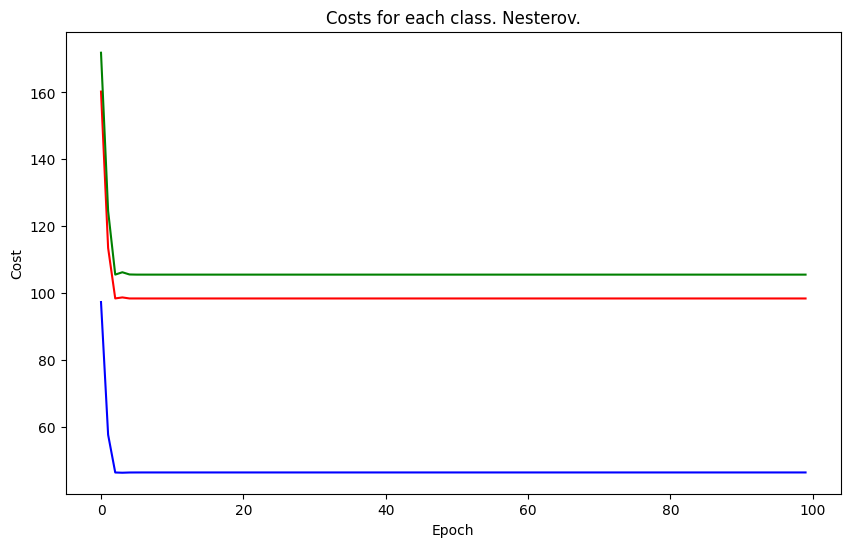

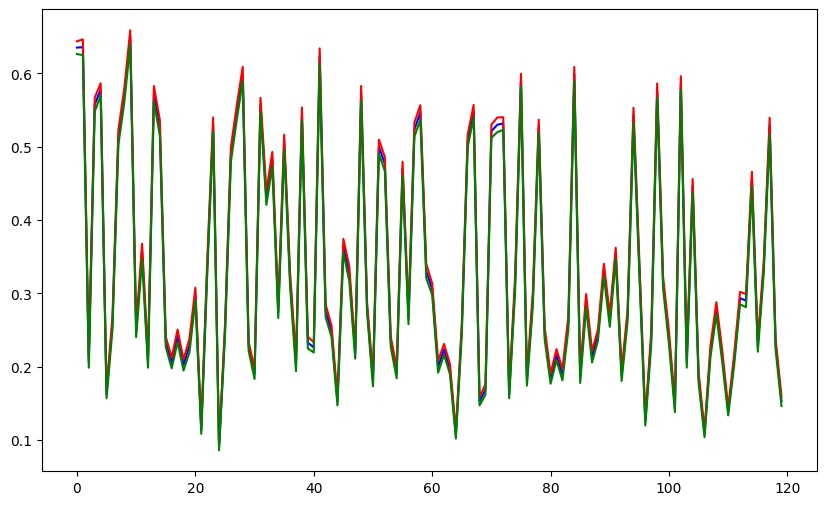

In [9]:
log_reg_nesterov_1 = LogReg(epochs = 100, lr = 0.001, optimization = 'Nesterov')
log_reg_nesterov_1.fit(X_train, Y_train_1)
preds_nesterov_1 = log_reg_nesterov_1.predict(X_test)
score_nesterov_1 = log_reg_nesterov_1.accuracy_score(preds_nesterov_1, Y_test_1)

print(score_nesterov_1)
print(preds_nesterov_1[:20])

log_reg_nesterov_2 = LogReg(epochs = 100, lr = 0.001, optimization = 'Nesterov')
log_reg_nesterov_2.fit(X_train, Y_train_2)
preds_nesterov_2 = log_reg_nesterov_2.predict(X_test)
score_nesterov_2 = log_reg_nesterov_2.accuracy_score(preds_nesterov_2, Y_test_2)

print(score_nesterov_2)
print(preds_nesterov_2[:20])

log_reg_nesterov_3 = LogReg(epochs = 100, lr = 0.001, optimization = 'Nesterov')
log_reg_nesterov_3.fit(X_train, Y_train_3)
preds_nesterov_3 = log_reg_nesterov_3.predict(X_test)
score_nesterov_3 = log_reg_nesterov_3.accuracy_score(preds_nesterov_3, Y_test_3)

print(score_nesterov_3)
print(preds_nesterov_3[:20])

plt.figure(figsize=(10, 6))
plt.title('Costs for each class. Nesterov.')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.plot(log_reg_nesterov_1.__COSTS__, color = 'blue', label = '1-st class')
plt.plot(log_reg_nesterov_2.__COSTS__, color = 'red', label = '2-st class')
plt.plot(log_reg_nesterov_3.__COSTS__, color = 'green', label = '3-st class')
plt.show()

# Одинаковые вероятности почему-то...
plt.figure(figsize=(10, 6))
plt.plot(log_reg_nesterov_1.__PROBS__[-1], color = 'blue')
plt.plot(log_reg_nesterov_2.__PROBS__[-1], color = 'red')
plt.plot(log_reg_nesterov_3.__PROBS__[-1], color = 'green')

plt.show()